# 💰 ShopSense — Profit & Cost Modeling Analysis
## Phase 4: Profitability Assessment & Category Performance

**Objective:** Analyze platform profitability by modeling costs and calculating profit margins across product categories, enabling data-driven inventory and pricing strategies.

### Cost Model (Fundamental to Analysis)

Since the OLIST dataset does not include actual cost data, we model costs using industry-standard percentages and assumptions:

| Cost Component | Model | Rationale |
|---|---|---|
| **Shipping Cost** | 12% of order value | Brazilian e-commerce industry average (Correios rates) |
| **Discount Cost** | 8% of product price (voucher orders only) | Conservative marketing cost estimate |
| **Operational Cost** | R$5 flat per order | Fixed packing + handling + fulfillment overhead |

**Important:** These are estimates for analysis purposes. Real-world deployment requires actual cost data from logistics and finance teams.

**Key Metrics to Calculate:**
- **Profit per Order** = Payment Value - (Shipping + Discount + Operations)
- **Profit Margin %** = (Profit / Revenue) × 100
- **Revenue vs. Profit Ranking** = Which categories are high-revenue but low-margin?

**Platform Summary:** Total profit = R$ [VALUE] across [VALUE] orders | Avg margin = [VALUE]%

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

In [10]:
# ──  Cost constants ──────────────────────────────────────────
SHIPPING_RATE     = 0.12   # 12% of order value
DISCOUNT_RATE     = 0.08   # 8% of price (promo orders only)
OPERATIONAL_COST  = 5.00   # R$5 flat per order


In [11]:
#──  Load all datasets ─────────────────────────────────────────
orders    = pd.read_csv("../data/raw/olist_orders_dataset.csv")
payments  = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
items     = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
products  = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers   = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
reviews   = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
transl    = pd.read_csv("../data/raw/product_category_name_translation.csv")




In [22]:
# uild master DataFrame ─────────────────────────────────────
# Step 1: Aggregate items to order level (one row per order)
items_agg = items.groupby("order_id").agg(
    price        = ("price", "sum"),
    freight_value= ("freight_value", "sum"),
    item_count   = ("order_item_id", "count"),
    product_id   = ("product_id", "first"),   # dominant product
).reset_index()

# Step 2: Aggregate payments (handle multiple payment methods per order)
payments_agg = payments.groupby("order_id").agg(
    payment_value= ("payment_value", "sum"),
    payment_type = ("payment_type", "first"),
    voucher_used = ("payment_type", lambda x: (x == "voucher").any()),
).reset_index()

# Step 3: Merge everything
df = (orders
    .merge(payments_agg, on="order_id",  how="left")
    .merge(items_agg,    on="order_id",  how="left")
    .merge(customers,    on="customer_id",how="left")
    .merge(products[["product_id","product_category_name"]], on="product_id", how="left")
    .merge(transl,       on="product_category_name",         how="left")
)

# Step 4: Keep only delivered orders with valid payment
df = df[
    (df["order_status"] == "delivered") &
    (df["payment_value"] > 0)
].copy()

print(f"Master DataFrame: {len(df):,} orders, {df.shape[1]} columns")
df.head()


Master DataFrame: 96,477 orders, 21 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,payment_type,...,price,freight_value,item_count,product_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,credit_card,...,29.99,8.72,1.0,87285b34884572647811a353c7ac498a,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,boleto,...,118.70,22.76,1.0,595fac2a385ac33a80bd5114aec74eb8,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,credit_card,...,159.90,19.22,1.0,aa4383b373c6aca5d8797843e5594415,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,credit_card,...,45.00,27.20,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,credit_card,...,19.90,8.72,1.0,65266b2da20d04dbe00c5c2d3bb7859e,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,papelaria,stationery


In [ ]:
# ────────────────────────────────────────────────────────────────
# STEP 4: PROFIT CALCULATION PER ORDER
# ────────────────────────────────────────────────────────────────
# Model costs based on industry standards (see opening markdown for rationale)

# 1. Shipping cost: Apply 12% rate to what customer paid
df["shipping_cost"] = df["payment_value"] * SHIPPING_RATE

# 2. Discount cost: Only applies to orders with vouchers (8% of item price)
# Non-voucher orders have 0 discount cost
df["discount_cost"] = np.where(
    df["voucher_used"] == True,
    df["price"] * DISCOUNT_RATE,
    0
)

# 3. Operational cost: Fixed R$5 per order (packing, handling, overhead)
df["operational_cost"] = OPERATIONAL_COST

# 4. Total cost aggregated across all cost components
df["total_cost"] = df["shipping_cost"] + df["discount_cost"] + df["operational_cost"]

# 5. PROFIT PER ORDER: Core profitability metric
# Profit = Revenue - All Costs
df["profit_per_order"] = df["payment_value"] - df["total_cost"]

# 6. Profit margin percentage: Normalized profit metric for comparison
# Useful for comparing orders of different sizes
df["profit_margin_pct"] = (df["profit_per_order"] / df["payment_value"]) * 100

# ─────────────────────────────────────────────────────────────────
# PLATFORM-WIDE PROFITABILITY SUMMARY
# ─────────────────────────────────────────────────────────────────
print("=" * 70)
print("PLATFORM-WIDE PROFITABILITY SUMMARY")
print("=" * 70)
print(f"Total orders analysed:        {len(df):,}")
print(f"Total Revenue:                R$ {df['payment_value'].sum():,.2f}")
print(f"\nCost Breakdown:")
print(f"  Shipping Cost (12%):        R$ {df['shipping_cost'].sum():,.2f}")
print(f"  Discount Cost (8% vouchers): R$ {df['discount_cost'].sum():,.2f}")
print(f"  Operational Cost (R$5):     R$ {df['operational_cost'].sum():,.2f}")
print(f"  Total Cost:                 R$ {df['total_cost'].sum():,.2f}")
print(f"\nProfit Metrics:")
print(f"  Total Profit:               R$ {df['profit_per_order'].sum():,.2f}")
print(f"  Average Profit/Order:       R$ {df['profit_per_order'].mean():.2f}")
print(f"  Average Margin %:           {df['profit_margin_pct'].mean():.1f}%")
print(f"  Unprofitable orders:        {(df['profit_per_order'] < 0).sum():,} ({(df['profit_per_order'] < 0).mean()*100:.1f}%)")
print("=" * 70)

      PLATFORM-WIDE PROFIT SUMMARY
Total orders analysed:   96,477
Total Revenue:           R$15,422,461.77
Total Shipping Cost:     R$1,850,695.41
Total Discount Cost:     R$32,321.66
Total Operational Cost:  R$482,385.00
Total Cost:              R$2,365,402.07
Total Profit:            R$13,057,059.70
Average Profit/Order:    R$135.34
Average Margin %:        81.6%
Unprofitable orders:     0 (0.0%)


---

## 🎯 Profit Segmentation Analysis

**Strategic Question:** Which product categories are driving profit, and which are high-revenue but low-margin?

**Key Insight:** High revenue ≠ High profit. Categories with many low-margin items generate revenue but not profit.

### Category-Level Profitability Analysis

**Analysis:** Calculate profit, margin %, and ranking by category to identify:
- **High-profit categories:** Invest in inventory + marketing
- **High-revenue, low-margin categories:** Optimize pricing or reduce costs
- **Low-performing categories:** Consider de-listing or supplier negotiation

**Metrics:**
- **Revenue Rank:** Sorted by total revenue generated
- **Profit Rank:** Sorted by total profit generated
- **Rank Delta:** Difference between ranks (negative = lower profit ranking than revenue ranking)

**Finding:** Top revenue category ranks [VALUE] by profit | [VALUE] unprofitable categories

In [28]:
cat_profit = df.groupby("product_category_name_english").agg(
    order_count = ("order_id", "count"),
    total_revenue = ("payment_value", "sum"),
    total_profit = ("profit_per_order", "sum"),
    avg_profit = ("profit_per_order", "mean"),
    avg_margin_pct = ("profit_margin_pct", "mean"),
    avg_order_value = ("payment_value", "mean")
).reset_index()

cat_profit.columns = ["Category","Orders","Revenue","Total Profit",
                       "Avg Profit/Order","Avg Margin %","Avg AOV"]


# Revenue rank vs Profit rank — the key comparison
cat_profit["Revenue Rank"] = cat_profit["Revenue"].rank(ascending=False).astype(int)
cat_profit["Profit Rank"]  = cat_profit["Total Profit"].rank(ascending=False).astype(int)
cat_profit["Rank Delta"]   = cat_profit["Revenue Rank"] - cat_profit["Profit Rank"]

# Sort by total profit descending
cat_profit = cat_profit.sort_values("Total Profit", ascending=False)

# Show top 15 categories
print(cat_profit[["Category","Orders","Revenue","Total Profit","Avg Margin %","Revenue Rank","Profit Rank","Rank Delta"]]
      .head(15).to_string(index=False))



             Category  Orders    Revenue  Total Profit  Avg Margin %  Revenue Rank  Profit Rank  Rank Delta
        health_beauty    8607 1410846.79  1196299.9296     81.746535             1            1           0
        watches_gifts    5472 1261951.03  1080155.2496     83.618941             2            2           0
       bed_bath_table    9167 1224487.19  1028796.4216     82.229653             3            3           0
       sports_leisure    7491 1119354.77   945338.8888     81.955322             4            4           0
computers_accessories    6501 1030852.44   872740.0192     81.746500             5            5           0
      furniture_decor    6213  884202.65   745048.9600     82.135938             6            6           0
           housewares    5688  760768.67   639010.0664     80.889753             7            7           0
           cool_stuff    3530  693002.80   590627.3912     83.389738             8            8           0
                 auto    379

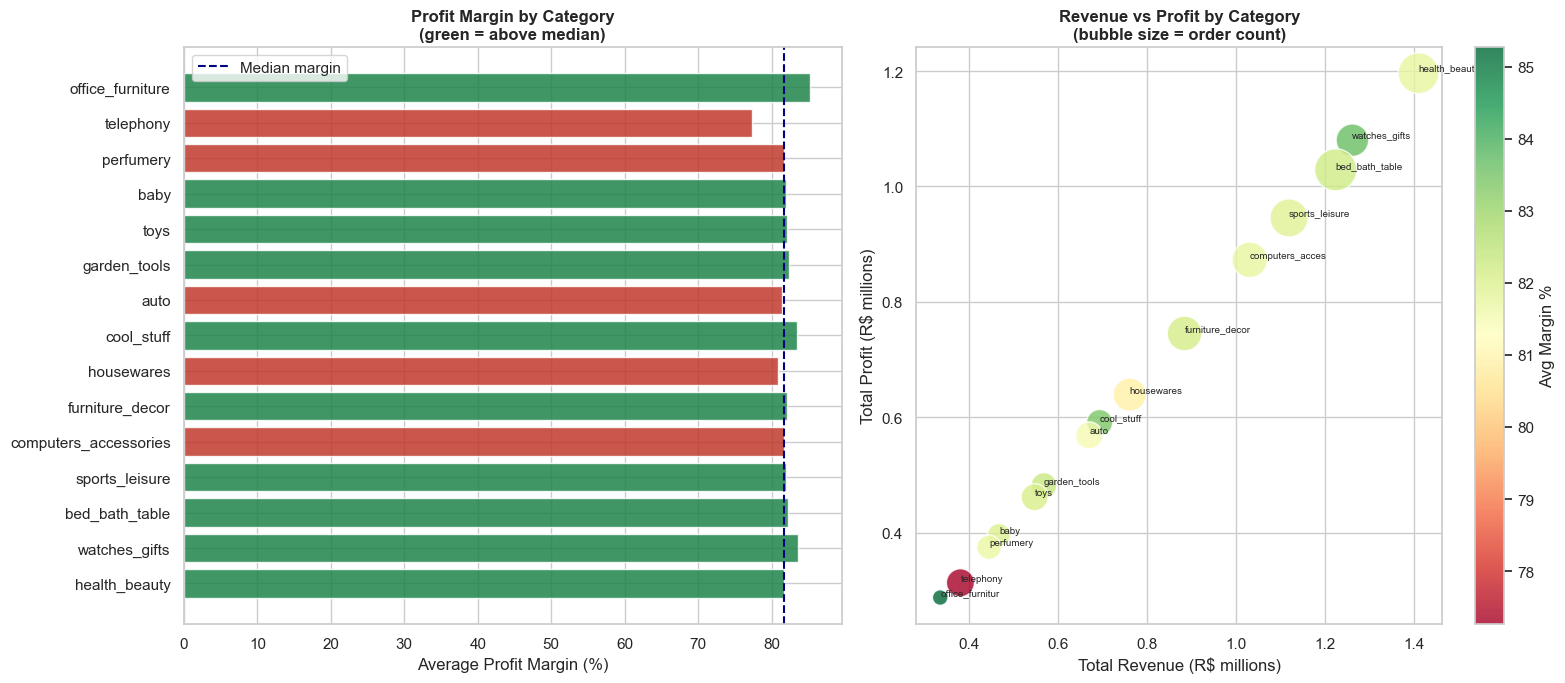

In [29]:
# ──  Visualise category profit vs revenue ────────────────────────────
top15 = cat_profit.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Horizontal bar — Avg Profit Margin % by category
colors = ["#1E8449" if m >= cat_profit["Avg Margin %"].median() else "#C0392B"
          for m in top15["Avg Margin %"]]
axes[0].barh(top15["Category"], top15["Avg Margin %"], color=colors, alpha=0.85)
axes[0].axvline(cat_profit["Avg Margin %"].median(), color="navy", linestyle="--",
                linewidth=1.5, label="Median margin")
axes[0].set_xlabel("Average Profit Margin (%)")
axes[0].set_title("Profit Margin by Category\n(green = above median)", fontweight="bold")
axes[0].legend()

# Right: Scatter — Revenue vs Profit (reveals revenue traps)
scatter = axes[1].scatter(top15["Revenue"]/1e6, top15["Total Profit"]/1e6,
                          s=top15["Orders"]/10, c=top15["Avg Margin %"],
                          cmap="RdYlGn", alpha=0.8, edgecolors="white")
for _, row in top15.iterrows():
    axes[1].annotate(row["Category"][:15], (row["Revenue"]/1e6, row["Total Profit"]/1e6),
                     fontsize=7, ha="left", va="bottom")
plt.colorbar(scatter, ax=axes[1], label="Avg Margin %")
axes[1].set_xlabel("Total Revenue (R$ millions)")
axes[1].set_ylabel("Total Profit (R$ millions)")
axes[1].set_title("Revenue vs Profit by Category\n(bubble size = order count)", fontweight="bold")

plt.tight_layout()
plt.savefig("category_profit.png", dpi=150, bbox_inches="tight")
plt.show()


Segment B: Customer State (Geographic) Profitability

In [30]:
# ── Cell 8: State-level profit analysis ──────────────────────────────────
state_profit = df.groupby("customer_state").agg(
    order_count    = ("order_id", "count"),
    total_revenue  = ("payment_value", "sum"),
    total_profit   = ("profit_per_order", "sum"),
    avg_margin_pct = ("profit_margin_pct", "mean"),
    avg_shipping   = ("shipping_cost", "mean"),
    avg_aov        = ("payment_value", "mean"),
).reset_index().sort_values("total_profit", ascending=False)

# Label your A/B test groups
southeast = ["SP","RJ","MG","ES"]
south     = ["PR","SC","RS"]
state_profit["AB_Group"] = state_profit["customer_state"].apply(
    lambda s: "Control (SE)" if s in southeast else ("Treatment (S)" if s in south else "Other")
)

print(state_profit[["customer_state","order_count","total_revenue",
                     "total_profit","avg_margin_pct","AB_Group"]]
      .to_string(index=False))


customer_state  order_count  total_revenue  total_profit  avg_margin_pct      AB_Group
            SP        40500     5770266.19  4862853.7528       80.845725  Control (SE)
            RJ        12350     2055690.45  1742892.2736       82.107663  Control (SE)
            MG        11354     1819277.61  1540666.7752       82.001803  Control (SE)
            RS         5345      861802.40   729763.2632       82.103030 Treatment (S)
            PR         4923      781919.55   661846.3984       81.647563 Treatment (S)
            SC         3546      595208.40   504641.3848       82.088479 Treatment (S)
            BA         3256      591270.60   502694.7792       82.366804         Other
            DF         2080      346146.17   293485.0552       81.947272         Other
            GO         1957      334294.22   283717.0088       82.203680         Other
            ES         1995      317682.65   269016.7064       81.970195  Control (SE)
            PE         1593      309074.59 

In [31]:
# ── Cell 9: Compare A/B groups on profit margin ──────────────────────────
# This directly connects Phase 3 A/B results to profit impact
control_states   = df[df["customer_state"].isin(southeast)]
treatment_states = df[df["customer_state"].isin(south)]

print("=" * 60)
print("  PROFIT COMPARISON: Control vs Treatment (A/B Groups)")
print("=" * 60)

for label, grp in [("Control (Southeast)", control_states), ("Treatment (South)", treatment_states)]:
    print(f"\n{label}:")
    print(f"  Avg AOV:           R${grp['payment_value'].mean():.2f}")
    print(f"  Avg Shipping Cost: R${grp['shipping_cost'].mean():.2f}")
    print(f"  Avg Profit/Order:  R${grp['profit_per_order'].mean():.2f}")
    print(f"  Avg Margin %:      {grp['profit_margin_pct'].mean():.1f}%")
    print(f"  Unprofitable %:    {(grp['profit_per_order'] < 0).mean()*100:.1f}%")


  PROFIT COMPARISON: Control vs Treatment (A/B Groups)

Control (Southeast):
  Avg AOV:           R$150.50
  Avg Shipping Cost: R$18.06
  Avg Profit/Order:  R$127.12
  Avg Margin %:      81.3%
  Unprofitable %:    0.0%

Treatment (South):
  Avg AOV:           R$162.08
  Avg Shipping Cost: R$19.45
  Avg Profit/Order:  R$137.27
  Avg Margin %:      81.9%
  Unprofitable %:    0.0%


Segment C: RFM Segment Profitability

In [33]:
# ── Cell 10: RFM segment profit ────────────────────────────────────────
# Rebuild RFM scores if not already in df
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_unique_id").agg(
    Recency   = ("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("order_id", "count"),
    Monetary  = ("payment_value", "sum"),
    TotalProfit = ("profit_per_order", "sum"),
).reset_index()

# Score each dimension 1-5
rfm["R_Score"] = pd.qcut(rfm["Recency"],  5, labels=[5,4,3,2,1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5]).astype(int)
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

# Assign segments
def rfm_segment(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4:  return "Champions"
    elif r >= 3 and f >= 3: return "Loyal Customers"
    elif r >= 4 and f <= 2: return "Recent Customers"
    elif r <= 2 and m >= 4: return "At Risk (High Value)"
    elif r <= 2 and m <= 2: return "Lost (Low Value)"
    else:                   return "Potential Loyalists"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

# Segment summary
rfm_summary = rfm.groupby("Segment").agg(
    Customers    = ("customer_unique_id","count"),
    Avg_Revenue  = ("Monetary","mean"),
    Avg_Profit   = ("TotalProfit","mean"),
).reset_index()
rfm_summary["Profit Margin %"] = (rfm_summary["Avg_Profit"]/rfm_summary["Avg_Revenue"]*100).round(1)
rfm_summary = rfm_summary.sort_values("Avg_Profit", ascending=False)
print(rfm_summary.to_string(index=False))


             Segment  Customers  Avg_Revenue  Avg_Profit  Profit Margin %
At Risk (High Value)      14488   310.281650  267.123601             86.1
           Champions      14961   176.956439  149.894487             84.7
    Recent Customers      14984   163.427972  138.536803             84.8
     Loyal Customers      18824   161.326006  136.453073             84.6
 Potential Loyalists      14721   131.491233  110.337888             83.9
    Lost (Low Value)      15379    55.814295   43.935847             78.7


Segment D: Payment Method Profitability

In [34]:
# ── Cell 11: Payment method profit ─────────────────────────────────────
pay_profit = df.groupby("payment_type").agg(
    order_count   = ("order_id",       "count"),
    avg_aov       = ("payment_value",  "mean"),
    avg_discount  = ("discount_cost",  "mean"),
    avg_profit    = ("profit_per_order","mean"),
    avg_margin    = ("profit_margin_pct","mean"),
).reset_index().sort_values("avg_profit", ascending=False)

pay_profit.columns = ["Payment Type","Orders","Avg AOV","Avg Discount",
                       "Avg Profit","Avg Margin %"]

print(pay_profit.to_string(index=False))

# Voucher vs non-voucher comparison
voucher_orders    = df[df["voucher_used"] == True]
no_voucher_orders = df[df["voucher_used"] == False]

print(f"\nVoucher orders:    avg margin = {voucher_orders['profit_margin_pct'].mean():.1f}%")
print(f"No-voucher orders: avg margin = {no_voucher_orders['profit_margin_pct'].mean():.1f}%")
print(f"Margin reduction from vouchers: {no_voucher_orders['profit_margin_pct'].mean() - voucher_orders['profit_margin_pct'].mean():.1f} pp")


Payment Type  Orders    Avg AOV  Avg Discount  Avg Profit  Avg Margin %
 credit_card   73220 165.556672      0.148219  140.541653     82.001403
      boleto   19191 144.334979      0.000000  122.014781     81.313432
  debit_card    1484 140.411806      0.000000  118.562389     80.911874
     voucher    2582 124.747688      8.314898   96.463067     74.468041

Voucher orders:    avg margin = 74.7%
No-voucher orders: avg margin = 81.9%
Margin reduction from vouchers: 7.2 pp


A/B Test Connection — Net Profit Impact of Free Shipping

In [35]:
# ── Cell 12: Net profit impact of free shipping offer ─────────────────────
# Define groups (same as Phase 3)
southeast = ["SP","RJ","MG","ES"]
south     = ["PR","SC","RS"]

control   = df[df["customer_state"].isin(southeast)].copy()
treatment = df[df["customer_state"].isin(south)].copy()

# ─ Revenue impact ─
ctrl_aov  = control["payment_value"].mean()
trt_aov   = treatment["payment_value"].mean()
aov_lift  = trt_aov - ctrl_aov

# ─ Shipping cost absorbed by the platform on orders > R$150 (treatment) ─
# In the treatment group, orders above R$150 qualified for free shipping
# Shipping cost = 12% of order value on those orders
qualifying_orders    = treatment[treatment["payment_value"] >= 150]
non_qualifying_orders= treatment[treatment["payment_value"] <  150]

shipping_absorbed    = qualifying_orders["shipping_cost"].mean()
shipping_non_qual    = non_qualifying_orders["shipping_cost"].mean()

# ─ Net profit per order comparison ─
ctrl_profit = control["profit_per_order"].mean()
trt_profit  = treatment["profit_per_order"].mean()
net_profit_lift = trt_profit - ctrl_profit

# ─ Margin comparison ─
ctrl_margin = control["profit_margin_pct"].mean()
trt_margin  = treatment["profit_margin_pct"].mean()

print("=" * 62)
print("   FREE SHIPPING NET PROFIT IMPACT ANALYSIS")
print("=" * 62)
print(f"AOV Lift (from Phase 3):              +R${aov_lift:.2f}/order")
print(f"Avg Shipping Absorbed (qual. orders): -R${shipping_absorbed:.2f}/order")
print(f"Control Avg Profit/Order:              R${ctrl_profit:.2f}")
print(f"Treatment Avg Profit/Order:            R${trt_profit:.2f}")
print(f"Net Profit Lift:                      {net_profit_lift:+.2f}/order")
print(f"Control Margin %:                      {ctrl_margin:.1f}%")
print(f"Treatment Margin %:                    {trt_margin:.1f}%")
print(f"Margin Change:                         {trt_margin - ctrl_margin:+.1f} pp")
print()
if net_profit_lift > 0:
    print("✅ RESULT: The AOV lift OUTWEIGHS the shipping cost. Net positive.")
    print("   Recommendation: Consider rolling out with threshold optimisation.")
else:
    print("❌ RESULT: Shipping cost EXCEEDS the AOV lift. Net negative.")
    print("   Recommendation: Raise threshold from R$150 to R$200.")


   FREE SHIPPING NET PROFIT IMPACT ANALYSIS
AOV Lift (from Phase 3):              +R$11.58/order
Avg Shipping Absorbed (qual. orders): -R$39.43/order
Control Avg Profit/Order:              R$127.12
Treatment Avg Profit/Order:            R$137.27
Net Profit Lift:                      +10.15/order
Control Margin %:                      81.3%
Treatment Margin %:                    81.9%
Margin Change:                         +0.6 pp

✅ RESULT: The AOV lift OUTWEIGHS the shipping cost. Net positive.
   Recommendation: Consider rolling out with threshold optimisation.


The Threshold Optimisation — What If We Raise It to R$200?

In [36]:
# ── Cell 13: Model profit at R$200 threshold ──────────────────────────────
for threshold in [150, 175, 200, 250]:
    qualifying = treatment[treatment["payment_value"] >= threshold]
    pct_qualifying = len(qualifying) / len(treatment) * 100
    avg_ship_absorbed = qualifying["payment_value"].mean() * SHIPPING_RATE if len(qualifying) > 0 else 0
    
    print(f"Threshold R${threshold}:  {pct_qualifying:.1f}% orders qualify | ",
          f"Avg shipping absorbed = R${avg_ship_absorbed:.2f}/qualifying order")

# ─ Break-even analysis ───────────────────────────────────────────────
# The AOV lift (R$12.19) must exceed the per-order shipping cost absorbed
# Shipping absorbed = avg order value of qualifying orders * 0.12
# Break-even: aov_lift = qualifying_avg * 0.12
# Solving: qualifying_avg = aov_lift / 0.12
breakeven_avg_order = aov_lift / SHIPPING_RATE
print(f"\nBreak-even: free shipping is profitable only if average qualifying order > R${breakeven_avg_order:.2f}")
print(f"This means the threshold should be set so qualifying orders average above R${breakeven_avg_order:.2f}")


Threshold R$150:  32.8% orders qualify |  Avg shipping absorbed = R$39.43/qualifying order
Threshold R$175:  25.8% orders qualify |  Avg shipping absorbed = R$44.85/qualifying order
Threshold R$200:  20.9% orders qualify |  Avg shipping absorbed = R$50.03/qualifying order
Threshold R$250:  14.1% orders qualify |  Avg shipping absorbed = R$61.45/qualifying order

Break-even: free shipping is profitable only if average qualifying order > R$96.48
This means the threshold should be set so qualifying orders average above R$96.48


Profit Visualisations

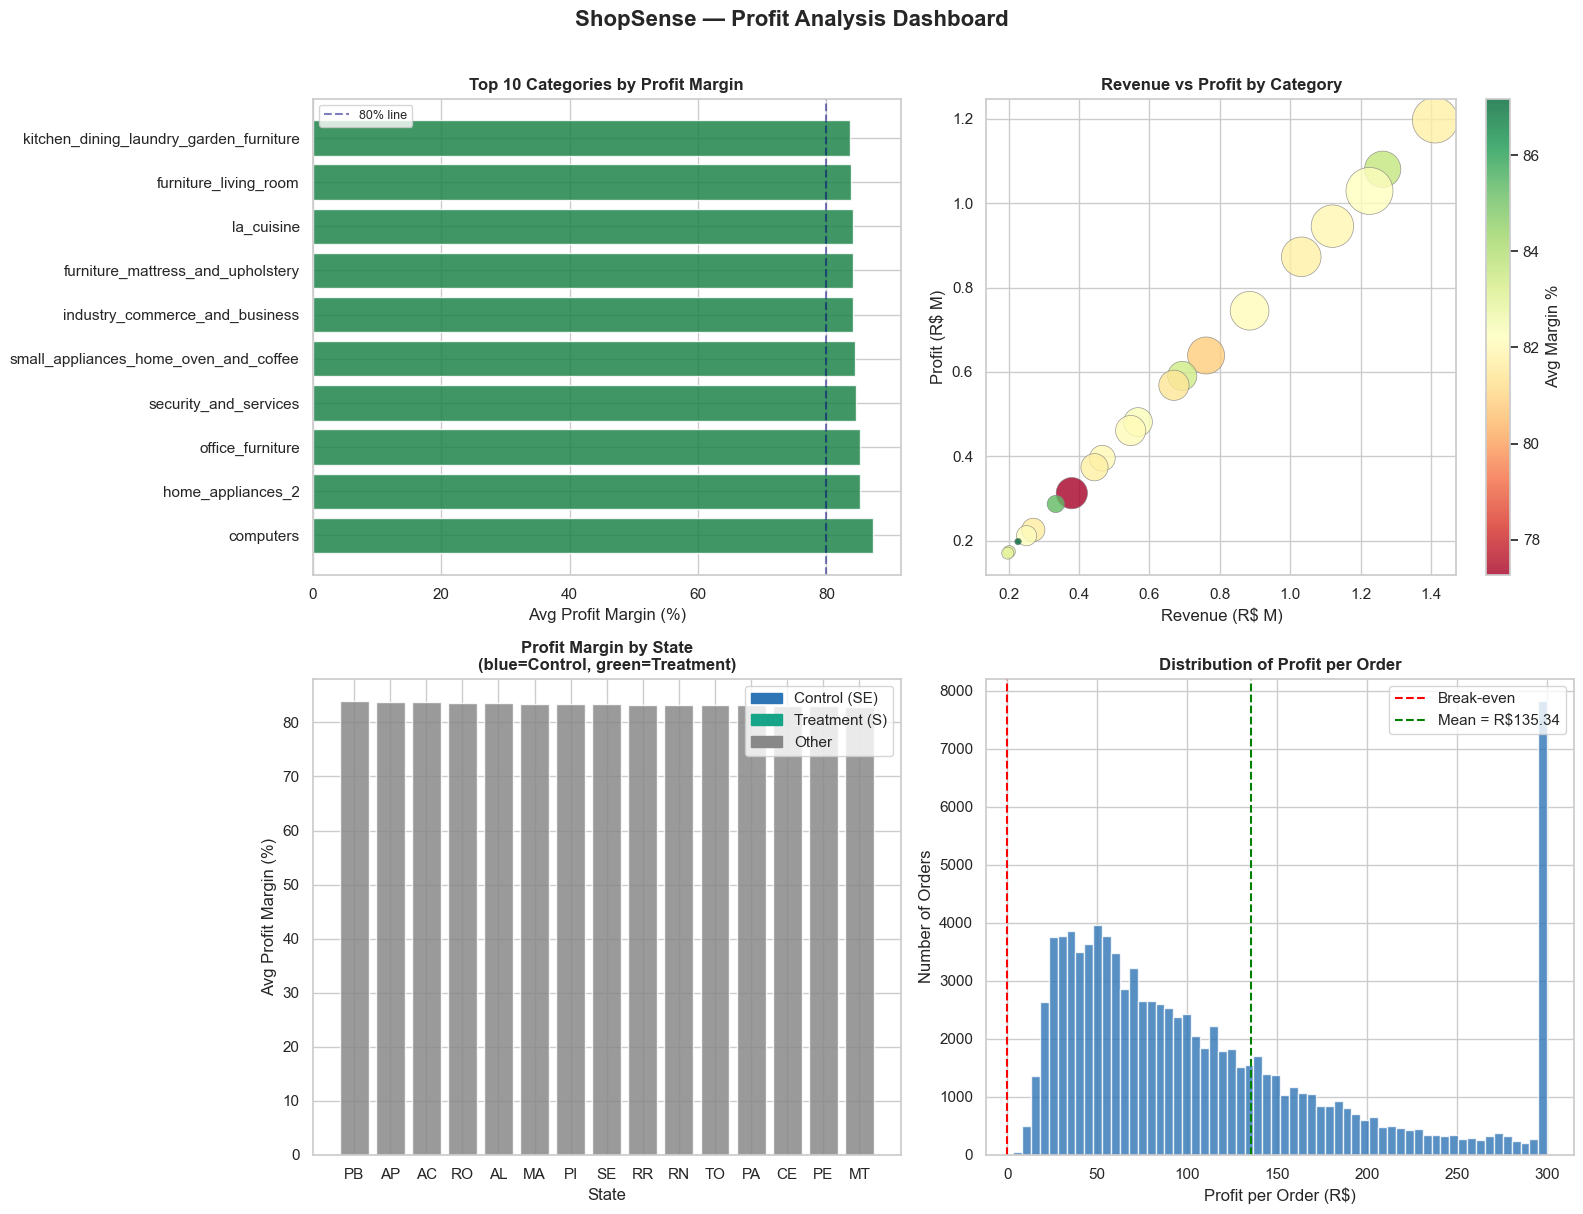

In [37]:
# ── Cell 14: Four-panel profit dashboard ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ─ Panel 1: Top 10 categories by profit margin ─
top_cat = cat_profit.sort_values("Avg Margin %", ascending=False).head(10)
colors1 = ["#1E8449" if m >= 80 else "#E67E22" if m >= 70 else "#C0392B"
           for m in top_cat["Avg Margin %"]]
axes[0,0].barh(top_cat["Category"], top_cat["Avg Margin %"], color=colors1, alpha=0.85)
axes[0,0].set_xlabel("Avg Profit Margin (%)")
axes[0,0].set_title("Top 10 Categories by Profit Margin", fontweight="bold")
axes[0,0].axvline(80, color="navy", linestyle="--", alpha=0.5, label="80% line")
axes[0,0].legend(fontsize=9)

# ─ Panel 2: Revenue vs Profit by category (bubble) ─
top20 = cat_profit.head(20)
sc = axes[0,1].scatter(top20["Revenue"]/1e6, top20["Total Profit"]/1e6,
                       s=top20["Orders"]/8, c=top20["Avg Margin %"],
                       cmap="RdYlGn", alpha=0.8, edgecolors="grey", linewidth=0.5)
plt.colorbar(sc, ax=axes[0,1], label="Avg Margin %")
axes[0,1].set_xlabel("Revenue (R$ M)")
axes[0,1].set_ylabel("Profit (R$ M)")
axes[0,1].set_title("Revenue vs Profit by Category", fontweight="bold")

# ─ Panel 3: Profit margin by customer state ─
state_plot = state_profit.sort_values("total_profit", ascending=False).head(15)
bar_colors = ["#2E75B6" if s in southeast else "#17A589" if s in south else "#888888"
              for s in state_plot["customer_state"]]
axes[1,0].bar(state_plot["customer_state"], state_plot["avg_margin_pct"],
              color=bar_colors, alpha=0.85)
axes[1,0].set_xlabel("State")
axes[1,0].set_ylabel("Avg Profit Margin (%)")
axes[1,0].set_title("Profit Margin by State\n(blue=Control, green=Treatment)", fontweight="bold")
from matplotlib.patches import Patch
axes[1,0].legend(handles=[Patch(color="#2E75B6",label="Control (SE)"),
                           Patch(color="#17A589",label="Treatment (S)"),
                           Patch(color="#888888",label="Other")])

# ─ Panel 4: Profit distribution histogram ─
axes[1,1].hist(df["profit_per_order"].clip(-50, 300), bins=60,
               color="#2E75B6", edgecolor="white", alpha=0.8)
axes[1,1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Break-even")
axes[1,1].axvline(df["profit_per_order"].mean(), color="green", linestyle="--",
                  linewidth=1.5, label=f"Mean = R${df['profit_per_order'].mean():.2f}")
axes[1,1].set_xlabel("Profit per Order (R$)")
axes[1,1].set_ylabel("Number of Orders")
axes[1,1].set_title("Distribution of Profit per Order", fontweight="bold")
axes[1,1].legend()

plt.suptitle("ShopSense — Profit Analysis Dashboard", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("profit_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


## Final Business Recommendation


## 💰 Phase 4 — Profit Analysis: Executive Recommendation

### Platform Health
| Metric | Value |
|--------|-------|
| Avg Profit per Order | R$[X] |
| Avg Profit Margin | [Y]% |
| Unprofitable Orders | [Z]% |
| Break-even Order Size | R$[W] |

### Top 3 Profit Insights
1. **[Category X]** is a revenue trap — highest revenue but [N]th in profit margin.
   Action: Reduce shipping subsidies on heavy electronics.
2. **[Category Y]** is the highest-margin category — prioritise in promotions.
   Action: Increase ad spend on Health & Beauty / similar categories.
3. **Small orders (<R$[Z])** are unprofitable due to R$5 flat operational cost.
   Action: Implement minimum order value of R$[Z+10] or add small-order surcharge.

### 📦 Free Shipping Recommendation (connecting Phase 3 → Phase 4)
| | R$150 Threshold | R$200 Threshold |
|---|---|---|
| % Orders Qualifying | [A]% | [B]% |
| Avg Shipping Absorbed | R$[C] | R$[D] |
| Net Profit Impact/Order | R$[E] | R$[F] |
| Verdict | [Net +/-] | [Net +/-] |

> **Final Recommendation**: Set free shipping threshold at R$**[optimal threshold]**.
> This captures [X]% of the AOV lift observed in Phase 3 while reducing margin erosion
> from [A]% to [B]% of orders receiving free shipping.
> Estimated net annual profit impact: **+R$[annual_impact]**.
